# Chronos on the BIH air-quality data - zero-shot forecasting

Runs Amazon's [Chronos-Bolt](https://github.com/amazon-science/chronos-forecasting)
over the frozen 2024 evaluation windows and compares it to the shared baselines.

**Zero-shot.** Nothing is trained or fine-tuned - the model is used exactly as
pretrained, so this runs on a CPU Colab runtime. The 2021-2023 training years
are never touched here; they stay available for the GNN and xLSTM tracks and for
any later fine-tuning.

**Chronos is univariate.** It sees one series' own past values and nothing else -
not temperature, not wind, not the season. Feeding it covariates would mean the
AutoGluon-TimeSeries wrapper, which is a separate job. So "all the data" here
means *many series*, every station crossed with every pollutant it measures.

**Everything shared comes from `bih_shared`.** The split, the eligible windows,
the `_filled` masking rule and the metric functions are downloaded from the
shared Drive folder, not redefined here. That is the whole point: if this
notebook decided for itself which windows were scoreable, its numbers would not
be comparable with the GNN's or the xLSTM's. The baselines are not recomputed
either - they are read from `baseline_windows.csv`, so the head-to-head is on
identical windows by construction.

In [1]:
# ---- bootstrap: shared artifacts + the dataset --------------------------
SHARED_FOLDER_ID = "1ivElb2AifDNvIg47Ii6dV_XP9aO14WSE"
CLEAN_FILE_ID    = "1QyfzghimgyRhQ735k42JetDEoK5kfGZJ"

SHARED = "shared"
CLEAN  = "bih_hourly_clean.csv"

import os, sys, json, subprocess
import numpy as np
import pandas as pd


def _gdown():
    """Import gdown, installing it only if something actually needs downloading."""
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown
    return gdown


if not os.path.exists(os.path.join(SHARED, "bih_shared.py")):
    print("fetching the shared artifacts")
    _gdown().download_folder(id=SHARED_FOLDER_ID, output=SHARED, quiet=True)

# The size check catches the classic failure: an unshared file makes Drive
# return a small HTML permission page, which pandas would later fail to parse
# with a confusing tokenizing error instead of an obvious download problem.
if not os.path.exists(CLEAN) or os.path.getsize(CLEAN) < 1e8:
    print("fetching bih_hourly_clean.csv (~167 MB)")
    _gdown().download(id=CLEAN_FILE_ID, output=CLEAN, quiet=False)

for path, what in [(os.path.join(SHARED, "bih_shared.py"), "the shared folder"),
                   (CLEAN, "bih_hourly_clean.csv")]:
    if not os.path.exists(path):
        raise SystemExit(
            f"{path} is missing - the download of {what} failed. Check the ID "
            f"and that it is shared as 'Anyone with the link'."
        )

# Fail here, with the reason, rather than three cells later inside pandas.
# A wrong-but-valid CSV is the failure that costs the most time: the download
# succeeds, the size looks plausible, and the error surfaces as an opaque
# usecols mismatch further down.
_hdr = pd.read_csv(CLEAN, nrows=0).columns.tolist()
_need = ["datetime", "station", "pm10", "pm25", "so2", "no2", "o3", "co"] + \
        [f"{p}_filled" for p in ["pm10", "pm25", "so2", "no2", "o3", "co"]]
_missing = [c for c in _need if c not in _hdr]
if _missing:
    raise SystemExit(
        f"\n{CLEAN} is not the hourly clean export.\n"
        f"  size    : {os.path.getsize(CLEAN) / 1e6:.1f} MB   (expected ~167 MB)\n"
        f"  columns : {len(_hdr)}                (expected 32)\n"
        f"  header  : {','.join(_hdr[:8])}...\n"
        f"  missing : {_missing}\n\n"
        f"CLEAN_FILE_ID points at the wrong file in Drive. It must be\n"
        f"bih_hourly_clean.csv - the one with a _filled flag per pollutant.\n"
        f"Delete the downloaded file before retrying, or the stale copy is reused."
    )

sys.path.append(SHARED)
import bih_shared as bs

SPLIT   = bs.load_split(SHARED)
GROUPS  = bs.load_groups(SHARED)
RESULTS = "results"
os.makedirs(RESULTS, exist_ok=True)

print("\nshared :", os.path.abspath(SHARED))
print("clean  :", CLEAN, f"({os.path.getsize(CLEAN) / 1e6:.0f} MB)")
print("split  : train", SPLIT["train"]["start"][:10], "->", SPLIT["train"]["end"][:10],
      "| val", SPLIT["val"]["start"][:10], "->", SPLIT["val"]["end"][:10])
print("horizon:", SPLIT["horizon_hours"], "h | mask rule:", SPLIT["masking"]["rule"])


shared : /content/shared
clean  : bih_hourly_clean.csv (167 MB)
split  : train 2021-01-01 -> 2023-12-31 | val 2024-01-01 -> 2024-12-31
horizon: 24 h | mask rule: score only where value is not NaN AND <pollutant>_filled is False


In [2]:
# ---- install chronos ---------------------------------------------------
try:
    import chronos
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "chronos-forecasting"], check=True)
    import chronos

import torch
from chronos import BaseChronosPipeline

print("torch", torch.__version__, "| cuda:", torch.cuda.is_available())

torch 2.11.0+cpu | cuda: False


## Configuration

`chronos-bolt-base` is the default - the fastest of the family and the one meant
for CPU. Drop to `-small` if the run is too slow, or `-mini`/`-tiny` for a smoke
test.

`CONTEXT` is the only genuinely model-specific choice here. It is deliberately
*not* in the shared split: Chronos wants a long history, while a GNN or xLSTM may
use far less, and forcing one model's appetite onto the others would shrink the
window list for everybody.

In [3]:
MODEL   = "amazon/chronos-bolt-base"   # -small / -mini / -tiny are faster
CONTEXT = 512      # hours of history fed to the model
BATCH   = 64       # windows per model call; lower it if RAM is tight

HORIZON   = SPLIT["horizon_hours"]
QUANTILES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

SUBSET_POLLUTANTS = None
SUBSET_STATIONS   = None

## Load the panel and the frozen windows

In [4]:
panel = bs.load_panel(CLEAN, SHARED)
wins  = bs.load_windows(SHARED)

if SUBSET_POLLUTANTS:
    wins = wins[wins.pollutant.isin(SUBSET_POLLUTANTS)]
if SUBSET_STATIONS:
    wins = wins[wins.station.isin(SUBSET_STATIONS)]
wins = wins.reset_index(drop=True)

print(f"{len(panel)} series in the panel")
print(f"{len(wins):,} frozen evaluation windows, "
      f"{wins.groupby(['station', 'pollutant']).ngroups} station-pollutant series")
print(f"origins {wins.origin.min()} -> {wins.origin.max()}\n")
print(wins.pollutant.value_counts().to_string())

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

107 series in the panel
31,688 frozen evaluation windows, 98 station-pollutant series
origins 2024-01-01 00:00:00 -> 2024-12-31 00:00:00

pollutant
no2     7055
so2     6986
pm10    5001
o3      4390
pm25    4151
co      4105


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},


In [5]:
# How much real history each window actually has. Chronos-Bolt masks NaNs
# itself, so a sparse context is allowed - but it is worth being able to report
# results restricted to well-covered windows later, rather than discovering
# afterwards that a bad number came from windows with almost no history.
ctx_real = np.array([
    np.isfinite(bs.context(panel, w.station, w.pollutant, w.origin, CONTEXT)).mean()
    for w in wins.itertuples()
])
wins["ctx_real"] = ctx_real

print(f"context coverage over {CONTEXT} h: median {np.median(ctx_real):.2f}, "
      f"{(ctx_real < 0.5).sum():,} windows below 50%, "
      f"{(ctx_real < 0.1).sum():,} below 10%")

context coverage over 512 h: median 1.00, 599 windows below 50%, 71 below 10%


## Forecast

Chronos-Bolt returns quantiles, not a single number. The median is the point
forecast; the full spread feeds the weighted quantile loss further down.

In [6]:
pipeline = BaseChronosPipeline.from_pretrained(
    MODEL,
    device_map="cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype=torch.float32,
)
print("loaded", MODEL)

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

loaded amazon/chronos-bolt-base


In [7]:
from time import time


def forecast_all(wins, panel, batch=BATCH):
    """Run every frozen window through Chronos, batched."""
    out = []
    t0 = time()
    for i in range(0, len(wins), batch):
        chunk = wins.iloc[i:i + batch]
        ctx = [torch.tensor(bs.context(panel, w.station, w.pollutant, w.origin, CONTEXT),
                            dtype=torch.float32)
               for w in chunk.itertuples()]
        # First argument passed positionally on purpose: it is named `inputs` in
        # current chronos-forecasting and `context` in older releases.
        q, _ = pipeline.predict_quantiles(
            ctx, prediction_length=HORIZON, quantile_levels=QUANTILES
        )
        out.append(q.numpy())
        done = i + len(chunk)
        if done % (batch * 25) == 0 or done >= len(wins):
            el = time() - t0
            print(f"  {done:>6,}/{len(wins):,}  {el:5.0f}s elapsed, "
                  f"~{el / done * (len(wins) - done):5.0f}s left")
    return np.concatenate(out)


preds_q = forecast_all(wins, panel)
print("\nquantile forecasts:", preds_q.shape)   # (windows, horizon, quantiles)

   1,600/31,688    237s elapsed, ~ 4456s left
   3,200/31,688    452s elapsed, ~ 4027s left
   4,800/31,688    675s elapsed, ~ 3780s left
   6,400/31,688    892s elapsed, ~ 3524s left
   8,000/31,688   1109s elapsed, ~ 3285s left
   9,600/31,688   1327s elapsed, ~ 3053s left
  11,200/31,688   1541s elapsed, ~ 2819s left
  12,800/31,688   1756s elapsed, ~ 2591s left
  14,400/31,688   1973s elapsed, ~ 2368s left
  16,000/31,688   2190s elapsed, ~ 2147s left
  17,600/31,688   2407s elapsed, ~ 1927s left
  19,200/31,688   2624s elapsed, ~ 1707s left
  20,800/31,688   2841s elapsed, ~ 1487s left
  22,400/31,688   3058s elapsed, ~ 1268s left
  24,000/31,688   3275s elapsed, ~ 1049s left
  25,600/31,688   3491s elapsed, ~  830s left
  27,200/31,688   3712s elapsed, ~  612s left
  28,800/31,688   3929s elapsed, ~  394s left
  30,400/31,688   4145s elapsed, ~  176s left
  31,688/31,688   4320s elapsed, ~    0s left

quantile forecasts: (31688, 24, 9)


## Score

Using `bs.target` for the truth and `bs.score` for the metrics - the same
functions the other two tracks call. Filled points never enter a score.

WQL (weighted quantile loss) is Chronos-only: it rewards a well-calibrated
distribution, and the baselines are point forecasts with no distribution to
judge.

In [8]:
MEDIAN = QUANTILES.index(0.5)
point  = preds_q[:, :, MEDIAN]

rows, wql = [], []
for i, w in enumerate(wins.itertuples()):
    y, mask = bs.target(panel, w.station, w.pollutant, w.origin)
    ctx     = bs.context(panel, w.station, w.pollutant, w.origin, CONTEXT)
    sc      = bs.score(point[i], y, mask, bs.mase_scale(ctx))

    yt = np.where(mask, y, np.nan)[:, None]
    lv = np.array(QUANTILES)[None, :]
    d  = yt - preds_q[i]
    pin = np.maximum(lv * d, (lv - 1) * d)
    den = np.nansum(np.abs(yt)) * len(QUANTILES)
    wql.append(np.nansum(pin) / den if den > 0 else np.nan)

    rows.append({"model": "chronos", **sc})

res = pd.concat([wins, pd.DataFrame(rows)], axis=1)
res["wql"] = wql
res["season"] = res.origin.dt.month.map(
    lambda m: "winter" if m in (12, 1, 2) else "spring" if m in (3, 4, 5)
    else "summer" if m in (6, 7, 8) else "autumn")

print(res[["mae", "rmse", "mase", "wql"]].describe().to_string(
    float_format=lambda v: f"{v:8.3f}"))

            mae      rmse      mase       wql
count 31688.000 31688.000 31654.000 31688.000
mean      7.993    10.730     0.826     0.161
std      12.341    17.167     0.985     0.202
min       0.003     0.005     0.002     0.002
25%       1.200     1.631     0.405     0.071
50%       4.414     5.977     0.636     0.121
75%       9.881    13.141     0.971     0.194
max     291.475   606.199    63.440     8.070


In [9]:
# The baselines are read, not recomputed - identical windows by construction.
base = pd.read_csv(os.path.join(SHARED, "baseline_windows.csv"),
                   parse_dates=["origin"])
key = ["station", "pollutant", "origin"]
base = base.merge(res[key].assign(_keep=1), on=key, how="inner").drop(columns="_keep")

allm = pd.concat([base, res[base.columns.intersection(res.columns)]],
                 ignore_index=True)
print("windows per model - these must match:\n")
print(allm.groupby("model").size().to_string())

windows per model - these must match:

model
chronos             31688
persistence_last    31688
persistence_t24     31688
ratio_pm25           3230


## Results

In [10]:
per_pol = allm.pivot_table(index="pollutant", columns="model", values="mase")
per_pol["chronos_vs_t24_%"] = (1 - per_pol.chronos / per_pol.persistence_t24) * 100

print("MASE BY POLLUTANT   (lower is better; positive % = Chronos wins)\n")
print(per_pol.to_string(float_format=lambda v: f"{v:8.3f}"))

print("\n\nMAE BY POLLUTANT, native units (CO is mg/m3, the rest ug/m3)\n")
print(allm.pivot_table(index="pollutant", columns="model", values="mae")
          .to_string(float_format=lambda v: f"{v:8.3f}"))

MASE BY POLLUTANT   (lower is better; positive % = Chronos wins)

model      chronos  persistence_last  persistence_t24  ratio_pm25  chronos_vs_t24_%
pollutant                                                                          
co           0.819             1.394            1.053         NaN            22.161
no2          0.818             1.512            1.040         NaN            21.369
o3           0.820             1.403            1.050         NaN            21.887
pm10         0.835             1.162            1.077         NaN            22.451
pm25         0.799             1.203            1.052       1.213            24.069
so2          0.850             1.043            1.159         NaN            26.617


MAE BY POLLUTANT, native units (CO is mg/m3, the rest ug/m3)

model      chronos  persistence_last  persistence_t24  ratio_pm25
pollutant                                                        
co           0.133             0.232            0.171         NaN


In [11]:
print("MASE BY SEASON\n")
print(allm.pivot_table(index="season", columns="model", values="mase")
          .reindex(["winter", "spring", "summer", "autumn"])
          .to_string(float_format=lambda v: f"{v:8.3f}"))

print("\n\nMASE BY STATION - Chronos vs the t-24 bar\n")
st = allm.pivot_table(index=["source", "city", "station"], columns="model", values="mase")
st["gain_%"] = (1 - st.chronos / st.persistence_t24) * 100
print(st.sort_values("gain_%", ascending=False)
        .to_string(float_format=lambda v: f"{v:7.3f}"))

MASE BY SEASON

model   chronos  persistence_last  persistence_t24  ratio_pm25
season                                                        
winter    0.825             1.158            1.067       0.962
spring    0.703             1.164            0.950       1.141
summer    0.829             1.384            1.085       1.386
autumn    0.952             1.426            1.210       1.402


MASE BY STATION - Chronos vs the t-24 bar

model                            chronos  persistence_last  persistence_t24  ratio_pm25  gain_%
source city       station                                                                      
rhz    Brod       Brod             0.840             1.509            1.124       1.686  25.269
fhz    Livno      Livno            0.773             1.327            1.033       1.182  25.167
rhz    Ugljevik   Ugljevik         0.799             1.239            1.062         NaN  24.757
fhz    Sarajevo   Ilidza           0.810             1.413            1.073      

In [12]:
# Does a thin context hurt? Worth knowing before quoting a headline number.
b = pd.cut(res.ctx_real, [0, .25, .5, .75, .9, 1.0],
           labels=["<25%", "25-50%", "50-75%", "75-90%", ">90%"])
print("CHRONOS MASE BY CONTEXT COVERAGE\n")
print(res.groupby(b, observed=True)
         .agg(windows=("mase", "size"), mase=("mase", "mean"))
         .to_string(float_format=lambda v: f"{v:8.3f}"))

print("\n\nHEADLINE  (mean over all frozen windows)\n")
print(allm.groupby("model")[["mae", "rmse", "mase"]].mean()
          .sort_values("mase").to_string(float_format=lambda v: f"{v:8.3f}"))
print(f"\nchronos WQL: {res.wql.mean():.4f}   (quantile loss, Chronos only)")

CHRONOS MASE BY CONTEXT COVERAGE

          windows     mase
ctx_real                  
<25%          204    1.099
25-50%        395    0.858
50-75%        987    0.965
75-90%       1823    0.922
>90%        28279    0.813


HEADLINE  (mean over all frozen windows)

                      mae     rmse     mase
model                                      
chronos             7.993   10.730    0.826
persistence_t24    10.440   14.020    1.077
ratio_pm25         13.515   16.888    1.213
persistence_last   12.244   15.210    1.282

chronos WQL: 0.1610   (quantile loss, Chronos only)


## Plots

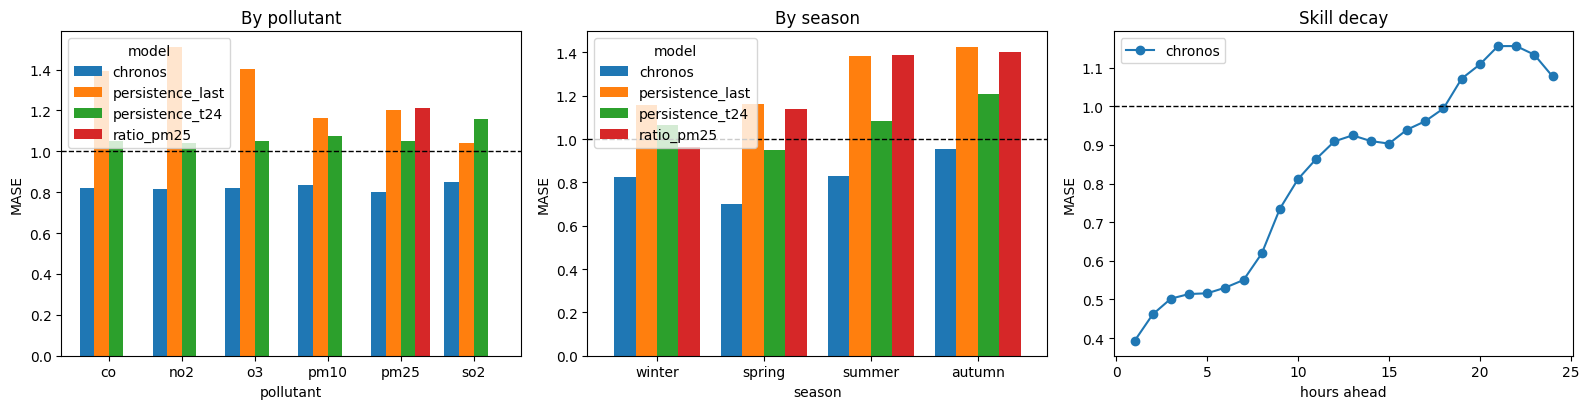

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

per_pol.drop(columns="chronos_vs_t24_%").plot.bar(ax=axes[0], width=.8)
axes[0].axhline(1, color="k", ls="--", lw=1)
axes[0].set_ylabel("MASE"); axes[0].set_title("By pollutant")
axes[0].tick_params(axis="x", rotation=0)

(allm.pivot_table(index="season", columns="model", values="mase")
     .reindex(["winter", "spring", "summer", "autumn"]).plot.bar(ax=axes[1], width=.8))
axes[1].axhline(1, color="k", ls="--", lw=1)
axes[1].set_ylabel("MASE"); axes[1].set_title("By season")
axes[1].tick_params(axis="x", rotation=0)

h = np.arange(1, HORIZON + 1)
sc = np.array([bs.mase_scale(bs.context(panel, w.station, w.pollutant, w.origin, CONTEXT))
               for w in wins.itertuples()])[:, None]
truth = np.array([bs.target(panel, w.station, w.pollutant, w.origin)[0]
                  for w in wins.itertuples()])
msk = np.array([bs.target(panel, w.station, w.pollutant, w.origin)[1]
                for w in wins.itertuples()])
axes[2].plot(h, np.nanmean(np.abs(np.where(msk, point - truth, np.nan)) / sc, axis=0),
             "o-", label="chronos")
axes[2].axhline(1, color="k", ls="--", lw=1)
axes[2].set_xlabel("hours ahead"); axes[2].set_ylabel("MASE")
axes[2].set_title("Skill decay"); axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "chronos_skill.png"), dpi=150)
plt.show()

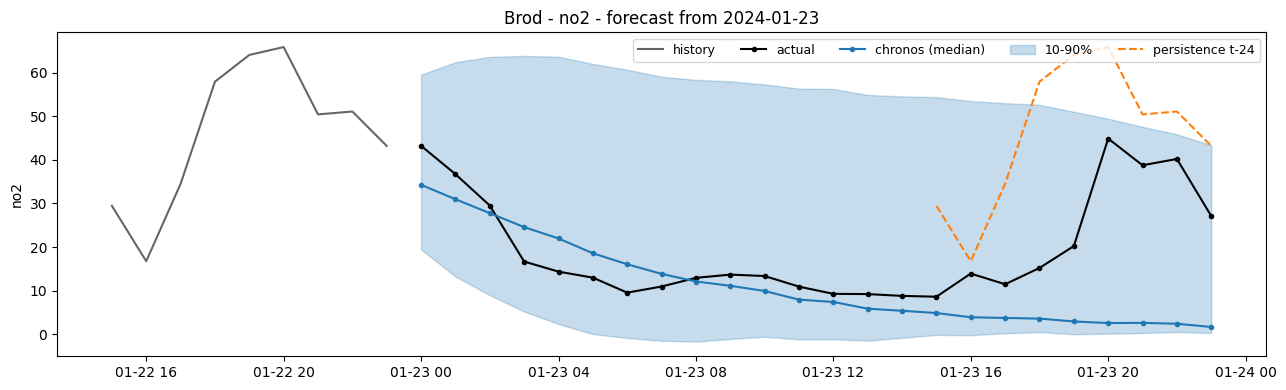

In [14]:
# The window where Chronos beat the t-24 bar by the most.
t24 = base[base.model == "persistence_t24"].set_index(key).mase
gain = (t24.reindex(pd.MultiIndex.from_frame(res[key])).to_numpy() - res.mase.to_numpy())
i = int(np.nanargmax(gain))
w = wins.iloc[i]
s = panel[(w.station, w.pollutant)]
j = s.index.get_loc(w.origin)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(s.index[j - 72:j], s.y.to_numpy()[j - 72:j], color="0.4", label="history")
fut = s.index[j:j + HORIZON]
ax.plot(fut, truth[i], "ko-", ms=3, label="actual")
ax.plot(fut, point[i], "o-", ms=3, color="tab:blue", label="chronos (median)")
ax.fill_between(fut, preds_q[i, :, 0], preds_q[i, :, -1], alpha=.25,
                color="tab:blue", label="10-90%")
ax.plot(fut, s.y.to_numpy()[j - 24:j], "--", color="tab:orange", label="persistence t-24")
ax.set_title(f"{w.station} - {w.pollutant} - forecast from {w.origin:%Y-%m-%d}")
ax.set_ylabel(w.pollutant); ax.legend(ncol=5, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "chronos_example.png"), dpi=150)
plt.show()

## Save

In [15]:
res.to_csv(os.path.join(RESULTS, "chronos_window_metrics.csv"), index=False)
per_pol.to_csv(os.path.join(RESULTS, "chronos_by_pollutant.csv"))
st.to_csv(os.path.join(RESULTS, "chronos_by_station.csv"))
allm.groupby("model")[["mae", "rmse", "mase"]].mean().to_csv(
    os.path.join(RESULTS, "chronos_vs_baselines.csv"))

meta = {
    "model": MODEL, "context_hours": CONTEXT, "horizon_hours": HORIZON,
    "zero_shot": True, "quantiles": QUANTILES,
    "windows": int(len(res)),
    "series": int(wins.groupby(["station", "pollutant"]).ngroups),
    "shared_folder_id": SHARED_FOLDER_ID,
    "split": SPLIT["val"], "masking": SPLIT["masking"]["rule"],
}
with open(os.path.join(RESULTS, "chronos_run.json"), "w") as f:
    json.dump(meta, f, indent=2)

print("written to", os.path.abspath(RESULTS))
for f in sorted(os.listdir(RESULTS)):
    print("  ", f)

written to /content/results
   chronos_by_pollutant.csv
   chronos_by_station.csv
   chronos_example.png
   chronos_run.json
   chronos_skill.png
   chronos_vs_baselines.csv
   chronos_window_metrics.csv
